In [5]:
import pandas as pd
import geopandas as gpd

In [6]:
data = gpd.read_file('distritos-peru@bogota-laburbano.geojson',encoding='utf8')[['nombdep','nombprov','nombdist']]
data = data.groupby(by=['nombdep','nombprov','nombdist']).size().reset_index()

deps = data['nombdep'].unique()
peru = {}
for dep in deps:
    temp_prov = {}
    provs = data[data['nombdep']==dep]['nombprov'].unique()
    for prov in provs:
        temp_prov.update({prov:[]})
        dists = data[(data['nombdep']==dep)&(data['nombprov']==prov)]['nombdist']
        for dist in dists:
            temp_prov[prov] += [dist]
    peru.update({dep:temp_prov})
    
noticias = pd.read_excel('with_sentiment.xlsx')
noticias

,Unnamed: 0,disease,date,title,body,tokens,domain,sentiment
0,0,antrax,2010-08-29,alarm camal chinch antrax,"chincha. Con cierta cautela, pero con mucha re...",chinch ciert cautel much respons vien tom auto...,diariocorreo,3
1,2,antrax,2012-01-12,detect dos cas antrax sam inclan,(María LLayque).- La muerte de dos terneras (c...,mari llayqu muert dos terner cri hembr vac rep...,diariocorreo,1
2,4,antrax,2014-02-27,tacn senas descart antrax hall ovej contagi human,"Miguel Quevedo, director del Senasa, confirmó ...",miguel queved director senas confirm cas antra...,rpp,3
3,6,antrax,2014-02-26,senas vacun ovin caprin poquer antrax,"El Director Ejecutivo de Senasa Tacna, Mario B...",director ejecut senas tacn mari bolan inform l...,diariocorreo,3
4,8,antrax,2014-02-25,confirm presenci antrax ovej,El director ejecutivo del Servicio Nacional de...,director ejecut servici nacional sanid agrari ...,elcomercio,3
...,...,...,...,...,...,...,...,...
10213,20144,zika,2024-04-28,luch deng piur mins dires fortalecer uso nuev ...,\n\n\n\nLa primera etapa consiste en el recojo...,primer etap cons recoj inform permitir defin d...,andina,3
10214,20145,zika,2024-05-08,mins incorpor fich tecnic prepar farmaceut rep...,\n\n\n\nEl “Repelente en gel” puede ser elabor...,repelent gel pued ser elabor prepar oficinal a...,andina,3
10215,20146,zika,2024-05-27,aument quinc cas guillain barr piur,A quince aumentaron los casos del Síndrome de ...,quinc aument cas sindrom guillain barr sgb reg...,diariocorreo,3
10216,20150,zika,2024-07-09,piur seis piuran sol recib agu maner constant,Para nadie es un secreto el pésimo servicio de...,nadi secret pesim servici agu potabl ofert eps...,noticiaspiura30,3


In [7]:
from tqdm import tqdm
tqdm.pandas()

def get_region(title:str,body:str):
    for dep, provs in peru.items():
        if f" {dep.lower()} " in title.lower() or f" {dep.lower()} " in body.lower():
            return dep
        
    for dep, provs in peru.items():   
        for prov, dists in provs.items():
            if f" {prov.lower()} " in title.lower() or f" {prov.lower()} " in body.lower():
                return dep
    
    for dep, provs in peru.items():   
        for prov, dists in provs.items():        
            for dist in dists:
                if f" {dist.lower()} " in title.lower() or f" {dist.lower()} " in body.lower():
                    return dep 
    return None

In [8]:
noticias['region'] = noticias.progress_apply(lambda x: get_region(x['title'],x['body']),axis=1)
noticias

 52%|█████▏    | 5300/10218 [00:46<00:42, 114.70it/s]


AttributeError: 'float' object has no attribute 'lower'

In [100]:
enf = pd.read_csv('df_enfermedades_final_VF.csv',index_col=0)
enf

,AÑO,SEMANA,ENFERMEDAD_UNIFICADA,CASOS_POR_SEMANA
0,2005,1,ANTRAX,0
1,2005,2,ANTRAX,0
2,2005,3,ANTRAX,0
3,2005,4,ANTRAX,0
4,2005,5,ANTRAX,0
...,...,...,...,...
27603,2024,11,ASMA,1059
27604,2024,12,ASMA,1313
27605,2024,13,ASMA,1179
27606,2024,14,ASMA,1263


In [101]:
mapping = {
    'immunopreventable': [
        'parálisis flácida aguda', 'varicela', 'tos ferina', 'fiebre amarilla',
        'tetanos', 'hepatitis b', 'meningitis', 'parotiditis', 'difteria'
    ],
    'metaxenic': [
        'dengue', 'malaria', 'chagas', 'leishmaniosis', 'bartonelosis',
        'chikungunya', 'zika'
    ],
    'zoonotic': [
        'loxoscelismo', 'peste bubonica', 'antrax', 'ofidismo', 'leptospirosis',
        'rabia', 'influenza aviar', 'mordedura de araña', 'mordedura de serpiente'
    ],
    'epidemic alert': [
        'asma', 'eda', 'infecciones respiratorias agudas', 'iras',
        'covid19', 'vih', 'sida', 'enfermedad diarreica aguda'
    ]
}

reverse_mapping = {disease.upper(): category.upper() for category, diseases in mapping.items() for disease in diseases}
enf['CATEGORIA'] = enf['ENFERMEDAD_UNIFICADA'].map(reverse_mapping)
enf

,AÑO,SEMANA,ENFERMEDAD_UNIFICADA,CASOS_POR_SEMANA,CATEGORIA
0,2005,1,ANTRAX,0,ZOONOTIC
1,2005,2,ANTRAX,0,ZOONOTIC
2,2005,3,ANTRAX,0,ZOONOTIC
3,2005,4,ANTRAX,0,ZOONOTIC
4,2005,5,ANTRAX,0,ZOONOTIC
...,...,...,...,...,...
27603,2024,11,ASMA,1059,EPIDEMIC ALERT
27604,2024,12,ASMA,1313,EPIDEMIC ALERT
27605,2024,13,ASMA,1179,EPIDEMIC ALERT
27606,2024,14,ASMA,1263,EPIDEMIC ALERT


C:\Users\isosc\AppData\Local\Temp\ipykernel_15988\3353061555.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enf_uniq['CASOS_POR_SEMANA'] = np.log10(enf_uniq['CASOS_POR_SEMANA'] + 1e+1) - 1
C:\Users\isosc\AppData\Local\Temp\ipykernel_15988\3353061555.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enf_uniq['Fecha'] = pd.to_datetime(


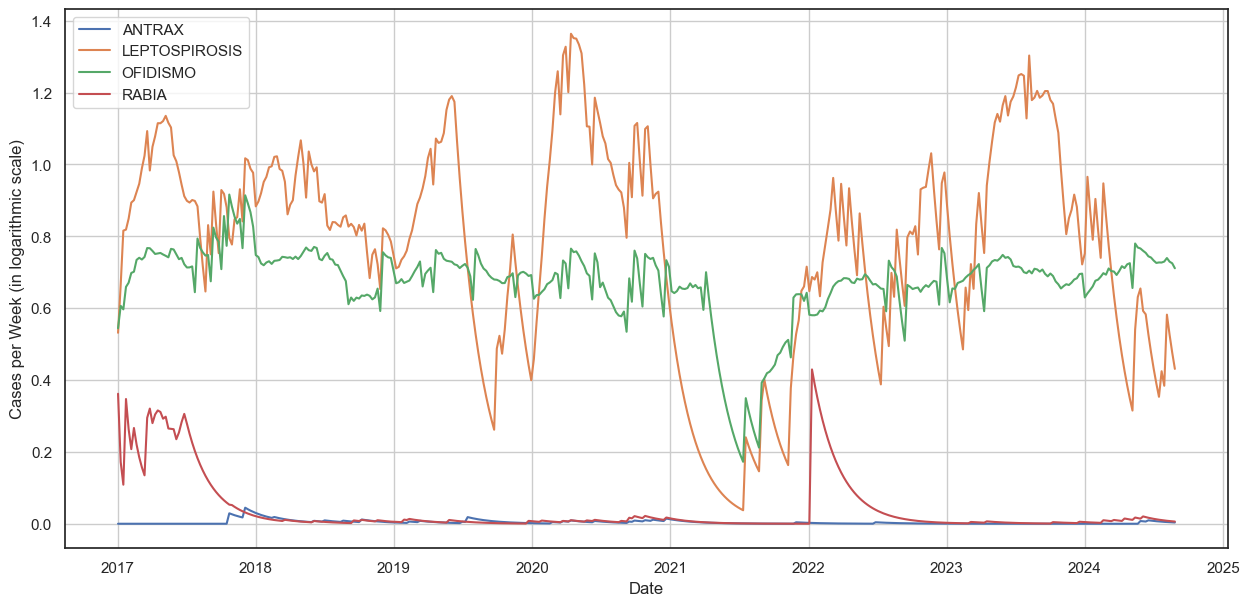

In [107]:
import matplotlib.pyplot as plt
import numpy as np

enf_uniq = enf[(enf['AÑO']>=2017)&(enf['CATEGORIA']=='ZOONOTIC')&(enf['ENFERMEDAD_UNIFICADA']!='ASMA')]
enf_uniq['CASOS_POR_SEMANA'] = np.log10(enf_uniq['CASOS_POR_SEMANA'] + 1e+1) - 1

enf_uniq['Fecha'] = pd.to_datetime(
    enf_uniq['AÑO'].astype(str) + '-W' + enf_uniq['SEMANA'].astype(str) + '-1', 
    format='%Y-W%W-%w'
)

time_series_data = enf_uniq.pivot(index='Fecha', columns='ENFERMEDAD_UNIFICADA', values='CASOS_POR_SEMANA')

window_size = 20  # 4-week moving average
sma_data = time_series_data.rolling(window=window_size).mean()
ema_data = time_series_data.ewm(span=window_size).mean()

plt.figure(figsize=(15, 7))
for category in ema_data.columns:
    plt.plot(ema_data.index, ema_data[category], label=category)

plt.xlabel("Date")
plt.ylabel("Cases per Week (in logarithmic scale)")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
import numpy as np

In [57]:
enf_uniq['CASOS_POR_SEMANA'] = np.log2(enf_uniq['CASOS_POR_SEMANA'] + 1e+1)


In [52]:
enf_uniq.to_csv('enf.csv')

In [51]:
enf_uniq.sort_values(by=['CASOS_POR_SEMANA'])

,AÑO,SEMANA,CATEGORIA,CASOS_POR_SEMANA
3401,2021,19,IMMUNOPREVENTABLE,3.321928
3389,2021,16,IMMUNOPREVENTABLE,3.321928
3387,2021,15,ZOONOTIC,3.321928
3386,2021,15,METAXENIC,3.321928
3385,2021,15,IMMUNOPREVENTABLE,3.321928
...,...,...,...,...
4056,2024,27,EPIDEMIC ALERT,19.963123
3656,2022,31,EPIDEMIC ALERT,20.194966
3028,2019,30,EPIDEMIC ALERT,20.426325
3684,2022,38,EPIDEMIC ALERT,20.478513


In [62]:
enf_uniq

,AÑO,SEMANA,CATEGORIA,CASOS_POR_SEMANA
2080,2015,1,EPIDEMIC ALERT,3.321928
2081,2015,1,IMMUNOPREVENTABLE,3.321928
2082,2015,1,METAXENIC,8.924813
2083,2015,1,ZOONOTIC,3.584963
2084,2015,2,EPIDEMIC ALERT,11.169925
...,...,...,...,...
4094,2024,38,EPIDEMIC ALERT,4.087463
4095,2024,39,EPIDEMIC ALERT,4.247928
4096,2024,40,EPIDEMIC ALERT,4.000000
4097,2024,41,EPIDEMIC ALERT,4.087463


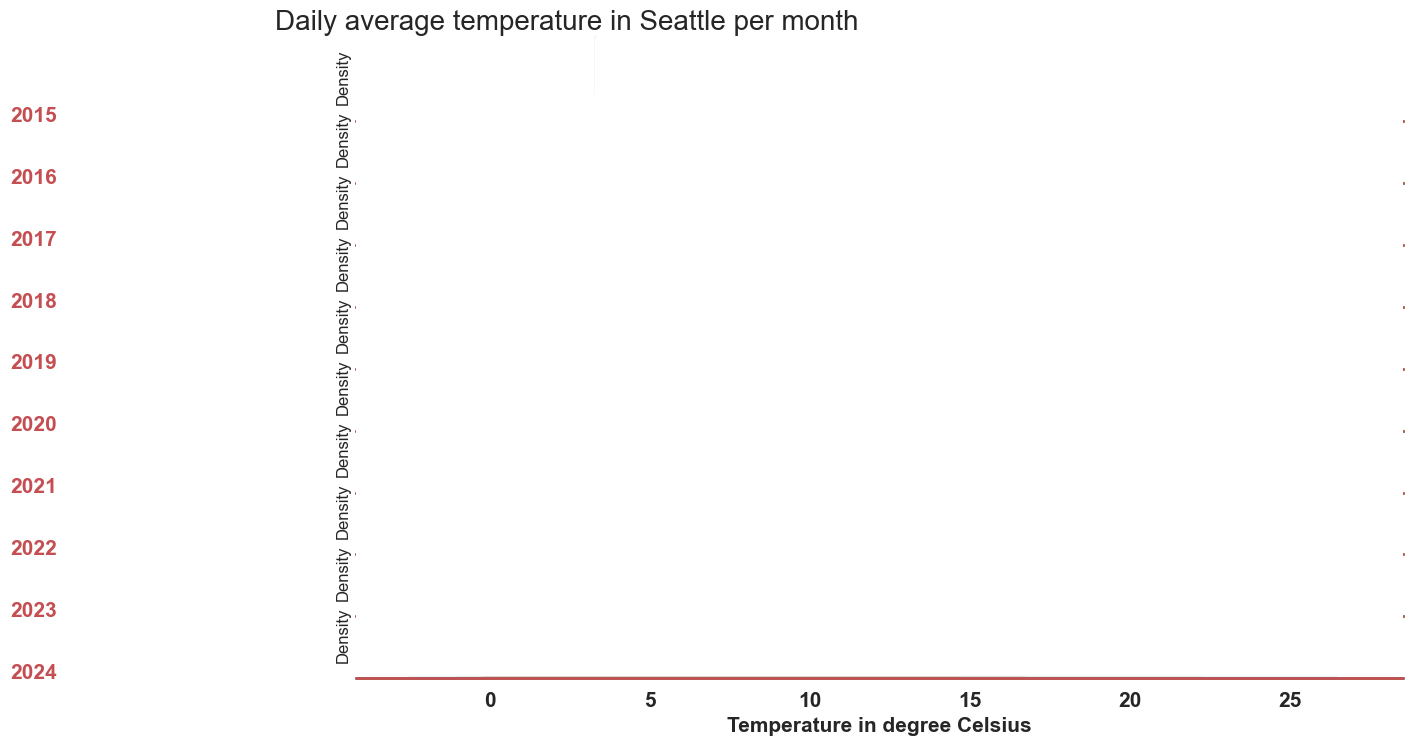

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

